In [2]:
import requests
import pandas as pd
import time
from datetime import date
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway
from datetime import timedelta
import os


In [ ]:
tmdb_api_key = input("Enter TMDB API key: ")

In [4]:
DEFAULT_START_DATE = "2000-01-01"
END_DATE = "2025-12-31"


def get_movies(start_date=DEFAULT_START_DATE, end_date=END_DATE):
    tmdb_url = "https://api.themoviedb.org/3/discover/movie"
    all_movies = []
    page = 1

    while True:
        params = {
            "api_key": tmdb_api_key,
            "page": page,
            "primary_release_date.gte": start_date,
            "primary_release_date.lte": end_date,
            "sort_by": "primary_release_date.asc",
            "vote_count.gte": 1,
            "with_origin_country": "US",
        }

        try:
            response = requests.get(tmdb_url, params=params)
            response.raise_for_status()
            movie_data = response.json()
        except requests.exceptions.RequestException:
            break

        results = movie_data.get("results", [])
        if not results:
            break

        all_movies.extend(results)
        print(f"Fetched page {page}")

        total_pages = movie_data.get("total_pages", 1)
        if page >= total_pages or page >= 5:
            break

        page += 1

    return all_movies

In [5]:
def get_movie_info(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": tmdb_api_key, "append_to_response": "credits"}

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        info_get = response.json()
    except requests.exceptions.RequestException:
        return None

    if (info_get.get("budget") or 0) == 0 or (info_get.get("revenue") or 0) == 0:
        return None

    return {
        "tmdb_id": movie_id,
        "title": info_get.get("title"),
        "release_date": info_get.get("release_date"),
        "runtime": info_get.get("runtime"),
        "budget": info_get.get("budget") or 0,
        "revenue": info_get.get("revenue") or 0,
        "cast": [c["name"] for c in info_get.get("credits", {}).get("cast", [])[:10]],
        "crew": [c["name"] for c in info_get.get("credits", {}).get("crew", [])[:10]],
        "countries": [
            c["iso_3166_1"] for c in info_get.get("production_countries", [])
        ],
        "status": info_get.get("status"),
        "overview": info_get.get("overview"),
        "popularity": info_get.get("popularity"),
        "vote_average": info_get.get("vote_average"),
        "vote_count": info_get.get("vote_count"),
        "tagline": info_get.get("tagline"),
        "genres": [g["name"] for g in info_get.get("genres", [])],
        "production_companies": [
            c["name"] for c in info_get.get("production_companies", [])
        ],
    }

In [6]:
def get_resume_start_date(output_path):
    if not os.path.exists(output_path):
        return DEFAULT_START_DATE

    existing_df = pd.read_csv(output_path)

    if existing_df.empty or "release_date" not in existing_df.columns:
        return DEFAULT_START_DATE

    existing_df["release_date"] = pd.to_datetime(
        existing_df["release_date"], errors="coerce"
    )

    latest_date = existing_df["release_date"].max()

    if pd.isna(latest_date):
        return DEFAULT_START_DATE

    next_date = latest_date + timedelta(days=1)
    return next_date.strftime("%Y-%m-%d")


def main():
    output_path = "../data/tmdb_movies.csv"

    start_date = get_resume_start_date(output_path)
    print(f"Starting from: {start_date}")

    dataset = []

    for movie in get_movies(start_date=start_date, end_date=END_DATE):
        movie_id = movie["id"]
        details = get_movie_info(movie_id)
        time.sleep(0.0001)

        print(f"Processing movie {movie_id}")

        if details:
            dataset.append(details)

    if not dataset:
        print("No new movies found.")
        return pd.DataFrame()

    df = pd.DataFrame(dataset)

    if os.path.exists(output_path):
        df.to_csv(output_path, mode="a", header=False, index=False)
    else:
        df.to_csv(output_path, index=False)

    print(f"Added {len(df)} rows to {output_path}")
    return df


if __name__ == "__main__":
    df = main()

Starting from: 2025-12-26
Fetched page 1
Fetched page 2
Processing movie 1604555
Processing movie 1579796
Processing movie 1534078
Processing movie 1464883
Processing movie 1636943
Processing movie 1606110
Processing movie 1605023
Processing movie 1601163
Processing movie 1630371
Processing movie 1607452
Processing movie 1600680
Processing movie 1595957
Processing movie 1340110
Processing movie 1658864
Processing movie 1601000
Processing movie 1619134
Processing movie 1606640
Processing movie 1606378
Processing movie 1591516
Processing movie 1559984
Processing movie 1605175
Processing movie 1587667
No new movies found.


In [ ]:
# df = df.drop_duplicates(subset=["tmdb_id"])
# df = df[(df["budget"] > 0) & (df["revenue"] > 0)]
# df = df[df["countries"].apply(lambda x: isinstance(x, list) and "US" in x)]

In [9]:
df_cpi = pd.read_excel("historical-cpi-u-202603.xlsx", skiprows=3)

df_cpi = df_cpi.drop(columns=["Indent Level"])

df_cpi.columns = [
    "year",
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

df_cpi["year"] = pd.to_numeric(df_cpi["year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["year"])

month_cols = df_cpi.columns[1:]
df_cpi[month_cols] = df_cpi[month_cols].apply(pd.to_numeric, errors="coerce")

df_cpi = df_cpi[(df_cpi["year"] >= 2000) & (df_cpi["year"] <= 2026)]

df_cpi["cpi"] = df_cpi[month_cols].mean(axis=1)

df_cpi = df_cpi[["year", "cpi"]]

df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

df = df.merge(df_cpi, left_on="release_year", right_on="year", how="left")

df = df[df["cpi"].notna()]

base_cpi = df_cpi.loc[df_cpi["year"] == 2025, "cpi"].iloc[0]

df["budget_adj"] = df["budget"] * (base_cpi / df["cpi"])
df["revenue_adj"] = df["revenue"] * (base_cpi / df["cpi"])

df["roi_adj"] = (df["revenue_adj"] - df["budget_adj"]) / df["budget_adj"]

print(df[["budget", "budget_adj", "revenue", "revenue_adj"]].head())
print("Missing CPI values:", df["cpi"].isna().sum())

     budget    budget_adj   revenue   revenue_adj
0      2883  5.390021e+03      2883  5.390021e+03
1  12000000  2.243505e+07    769272  1.438221e+06
2   6000000  1.121753e+07  35547761  6.645966e+07
3  11000000  2.056546e+07  59827328  1.118524e+08
4  90000000  1.682629e+08  14828081  2.772240e+07
Missing CPI values: 0


In [10]:
df = df[df["cpi"].notna()]
df = df[df["budget_adj"] > 0]
df = df[df["revenue_adj"] > 0]
df = df.dropna(subset=["roi_adj"])

## Simple Data Overview

In [11]:
# Table: Rows represent a movie and each feature of the movie is being shown as a distinct column 

# Number of movies, columns
num_movies, num_columns = df.shape
print(f"Dataset: {num_movies} movies, {num_columns} columns")
print()

# columns and its data type
print("Columns and the data type:")
print(df.dtypes)

# Columns with missing data 
missing = df.isnull().sum()
print(f"Missing values: {missing}")
#just tagline and overview missing

# Test of 5 movies, using just 5 features for now to simplify visually
print("5 sample films:")
display(df[["title", "release_date", "budget_adj", "revenue_adj", "roi_adj", "genres"]].head())

Dataset: 5266 movies, 23 columns

Columns and the data type:
tmdb_id                   int64
title                    object
release_date             object
runtime                   int64
budget                    int64
revenue                   int64
cast                     object
crew                     object
countries                object
status                   object
overview                 object
popularity              float64
vote_average            float64
vote_count                int64
tagline                  object
genres                   object
production_companies     object
release_year              int32
year                    float64
cpi                     float64
budget_adj              float64
revenue_adj             float64
roi_adj                 float64
dtype: object
Missing values: tmdb_id                   0
title                     0
release_date              0
runtime                   0
budget                    0
revenue                   0
cast 

,title,release_date,budget_adj,revenue_adj,roi_adj,genres
0,The Dirt on Soap,2000-01-01,5.390021e+03,5.390021e+03,0.000000,"['Animation', 'Family']"
1,Passion of Mind,2000-01-07,2.243505e+07,1.438221e+06,-0.935894,"['Drama', 'Romance']"
2,My Dog Skip,2000-01-12,1.121753e+07,6.645966e+07,4.924627,"['Comedy', 'Drama', 'Family']"
3,Next Friday,2000-01-12,2.056546e+07,1.118524e+08,4.438848,['Comedy']
4,Supernova,2000-01-14,1.682629e+08,2.772240e+07,-0.835244,"['Science Fiction', 'Horror', 'Thriller']"


## ROI Distribution

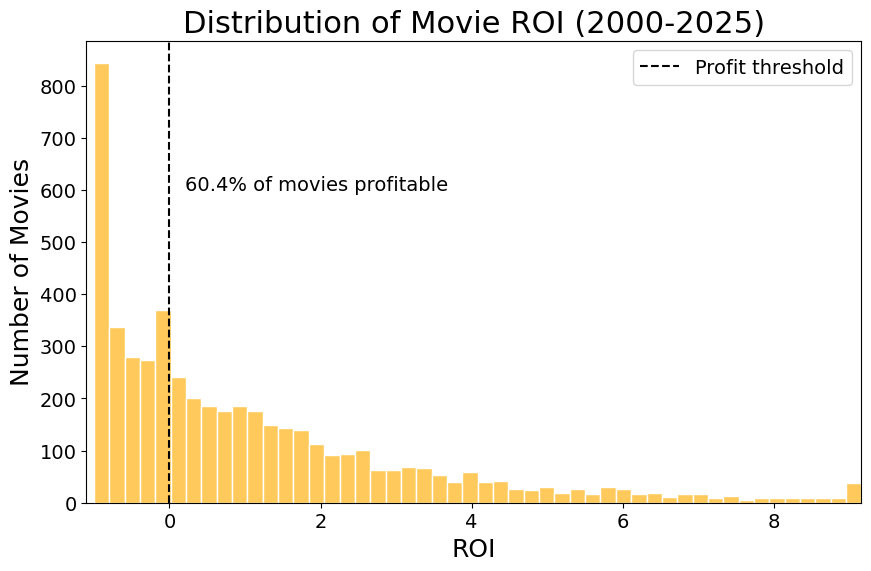

In [ ]:
import matplotlib.pyplot as plt

#Let me know if I should adjust the plot to make the x axis shorter in length! 

#Feel free to mess around with colors and stuff, trying to keep it consistent w/ slides color scheme

#Also I made the font size and stuff bigger than normal since prof mentioned it a bunch during slide notes, feel free to alter too! 
roi_data = df[df["roi_adj"] <= df["roi_adj"].quantile(0.95)]["roi_adj"] #tweaking size for outliers
plt.figure(figsize=(10, 6))
plt.hist(roi_data, bins=50, color="#ffca5b", edgecolor="white") #switched color to match yellow on slide deck
plt.axvline(0, color="black", linestyle="--", label="Profit threshold")
plt.xlim(-1.1, roi_data.max()) #max loss is evidently -1 so starting plot there 
plt.title("Distribution of Movie ROI (2000-2025)", fontsize=22)
plt.xlabel("ROI", fontsize=18)
plt.ylabel("Number of Movies", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.text(0.2, 600, "60.4% of movies profitable", fontsize=14, color="black") 
# wanted to put this line ^ above since the distribution is a bit deceiving but not needed if you guys think it's overkill 
plt.show()

## Budget/Revenue Scatter

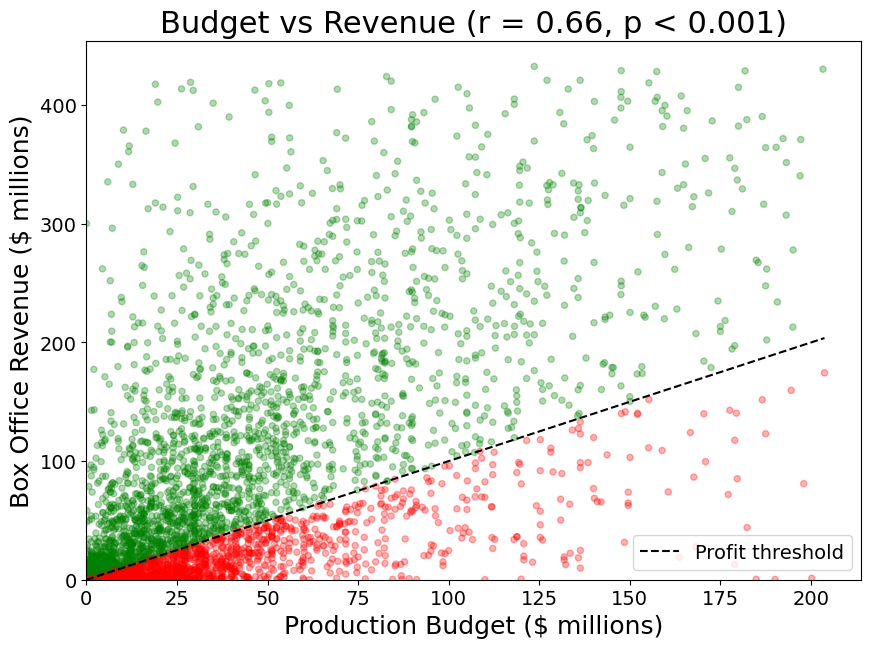

In [13]:
import matplotlib.pyplot as plt
from scipy import stats

# looks a little funky at parts due to the rounding of some of the production budgets ;/

# debating whether to put red/green label legend, but fear it may congest the screen too much?

# visually doesn't show the loss-making movies since they clump at bottom so much 

plot_df = df[df["revenue_adj"] > 0].copy() #removed the Some Bears movie that had a -12
plot_df = plot_df[plot_df["budget_adj"] <= plot_df["budget_adj"].quantile(0.95)] #removing crazy expensive movies/outliers
plot_df = plot_df[plot_df["revenue_adj"] <= plot_df["revenue_adj"].quantile(0.95)] #removing crazy expensive movies/outliers

# Correlation
r, p = stats.pearsonr(plot_df["budget_adj"], plot_df["revenue_adj"])

# Color by profit or loss
colors = plot_df["roi_adj"].apply(lambda x: "green" if x > 0 else "red")

plt.figure(figsize=(10, 7))
plt.scatter(
    plot_df["budget_adj"] / 1000000,
    plot_df["revenue_adj"] / 1000000,
    alpha=0.3, # was having trouble settling on alpha/opacity to try to best see clumps.. feel free to mess around with it! 
    c=colors,
    s=20
)

# profit threshold line
max_val = plot_df["budget_adj"].max() / 1000000
plt.plot([0, max_val], [0, max_val], "k--", linewidth=1.5, label="Profit threshold")

plt.title(f"Budget vs Revenue (r = {r:.2f}, p < 0.001)", fontsize=22)
plt.xlabel("Production Budget ($ millions)", fontsize=18)
plt.ylabel("Box Office Revenue ($ millions)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.xlim(0, None)
plt.ylim(0, None)
plt.show()

## ROI distribution by Genre

<Figure size 1400x700 with 0 Axes>

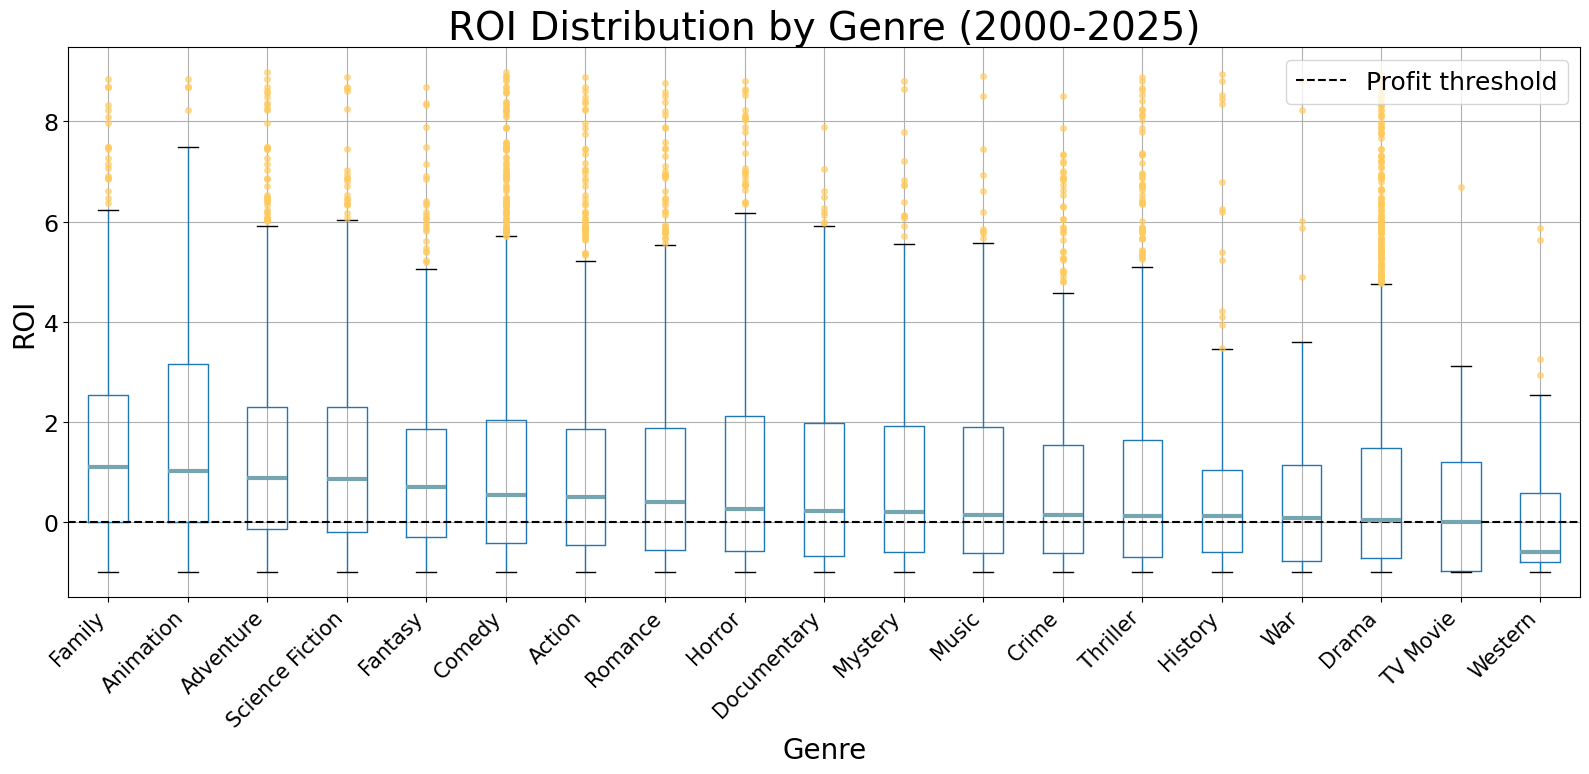

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# followed this tutorial  - https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html


# Converting to py lists
df_genres = df.explode("genres").dropna(subset=["genres"])

# using explode so each genre listed for a movie is seperated for own row
# let me know if you guys think I should do it only for the first genre given instead 

# explode explanationn - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html 
df_genres = df.explode("genres").dropna(subset=["genres"])

# removing outliers 
roi_cap = df_genres["roi_adj"].quantile(0.95)
df_genres = df_genres[df_genres["roi_adj"] <= roi_cap]

# sorting by median roi
ordered_genres = (
    df_genres.groupby("genres")["roi_adj"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
df_genres["genres"] = pd.Categorical(df_genres["genres"], categories=ordered_genres, ordered=True)
df_genres = df_genres.sort_values("genres")

plt.figure(figsize=(14, 7))
df_genres.boxplot(
    column="roi_adj",
    by="genres",
    figsize=(16, 8),
    flierprops=dict(marker='o', markersize=4, alpha=0.6, markerfacecolor="#ffca5b", markeredgecolor="#ffca5b"), #using color from slides to match 
    medianprops=dict(color="#75a5b0", linewidth=3) #using color from slides to match
)

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/marker_reference.html used this for outliers and marker stuff  

plt.title("ROI Distribution by Genre (2000-2025)", fontsize=28)
plt.suptitle("") # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.suptitle.html its auto added by mpl, so had to remove
plt.xlabel("Genre", fontsize=20)
plt.ylabel("ROI", fontsize=20)
plt.xticks(rotation=45, ha="right", fontsize=15) #prof mentioned being nitpicky about rotating axis ticks :()
plt.yticks(fontsize=17)
plt.axhline(0, color="black", linestyle="--", label="Profit threshold")
plt.legend(fontsize=18, loc="upper right")
plt.tight_layout()
plt.show()